Loading Library

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading Data

In [4]:
df=pd.read_csv('/content/diabetes_prediction_dataset.csv')

In [5]:
df.head(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [6]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99982 entries, 0 to 99981
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               99982 non-null  object 
 1   age                  99982 non-null  float64
 2   hypertension         99982 non-null  int64  
 3   heart_disease        99982 non-null  int64  
 4   smoking_history      99982 non-null  object 
 5   bmi                  99982 non-null  float64
 6   HbA1c_level          99982 non-null  float64
 7   blood_glucose_level  99982 non-null  int64  
 8   diabetes             99982 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


No Missing Values

In [7]:
df.gender.value_counts()

,count
gender,
Female,58552
Male,41430


In [8]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000
mean,41.888076,0.074863,0.039427,27.320757,5.527529,138.057810,0.085015
std,22.517206,0.263172,0.194610,6.636853,1.070665,40.709469,0.278906
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.000000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [9]:
df[df['age']<1]

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
155,Female,0.08,0,0,No Info,14.43,6.5,160,0
218,Female,0.56,0,0,No Info,16.85,5.0,140,0
241,Male,0.88,0,0,No Info,17.49,6.0,140,0
268,Female,0.16,0,0,No Info,12.15,6.6,100,0
396,Male,0.16,0,0,No Info,14.35,6.5,126,0
...,...,...,...,...,...,...,...,...,...
99434,Male,0.32,0,0,No Info,15.93,5.7,100,0
99518,Female,0.40,0,0,No Info,16.66,3.5,140,0
99611,Female,0.64,0,0,No Info,17.58,6.1,140,0
99760,Female,0.32,0,0,No Info,12.26,5.8,126,0


In [10]:
df=df[df['age']>=18]

In [11]:
df['age'].describe()

,age
count,82767.000000
mean,48.858966
std,18.014490
min,18.000000
25%,34.000000
50%,49.000000
75%,63.000000
max,80.000000


In [12]:
df.head(2)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0


Checking Missing Values

In [13]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [14]:
df.drop(columns=['smoking_history'],inplace=True)

In [15]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


Data contains no missing values

# EDA

Multi-Panel Histograms by Diabetes

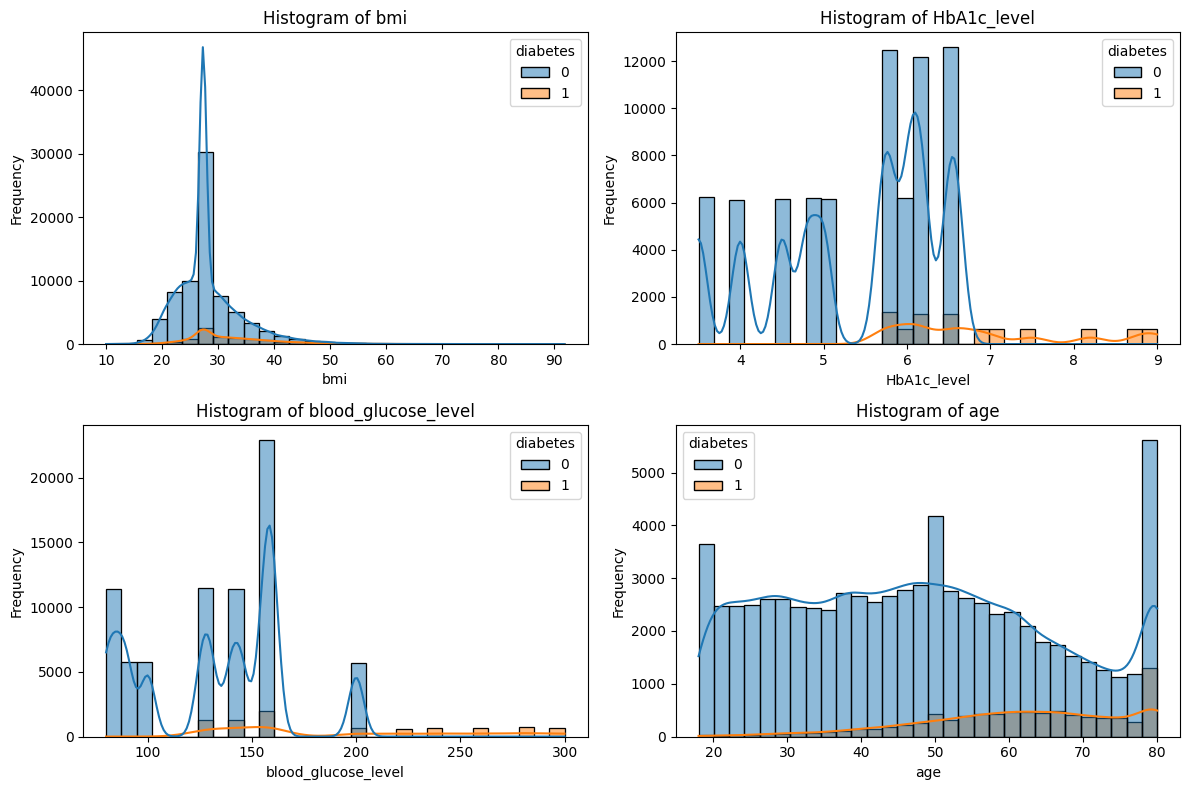

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables to plot
cols = ['bmi', 'HbA1c_level', 'blood_glucose_level', 'age']

# Create subplot grid (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes = axes.flatten()

# Loop through variables
for i, col in enumerate(cols):
    sns.histplot(data=df, x=col, hue='diabetes',
                 kde=True, bins=30, ax=axes[i])

    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

 Boxplot Comparison of Numerical Variables by Diabetes Status

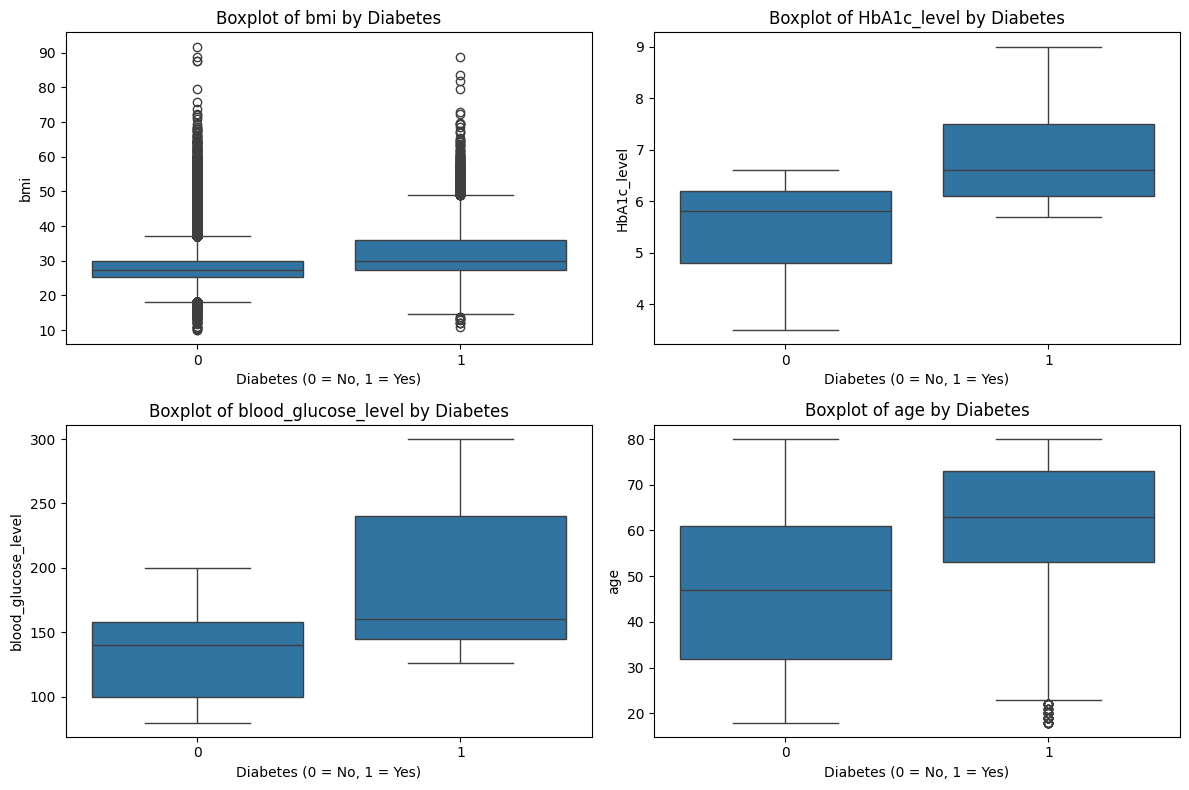

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select your numerical columns
cols = ['bmi', 'HbA1c_level', 'blood_glucose_level', 'age']

# Create subplot grid (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# Plot boxplots
for i, col in enumerate(cols):
    sns.boxplot(data=df, x='diabetes', y=col, ax=axes[i])

    axes[i].set_title(f'Boxplot of {col} by Diabetes')
    axes[i].set_xlabel('Diabetes (0 = No, 1 = Yes)')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

Class Imbalance Check

In [18]:
df['diabetes'].value_counts(normalize=True)*100

,proportion
diabetes,
0,89.82928
1,10.17072


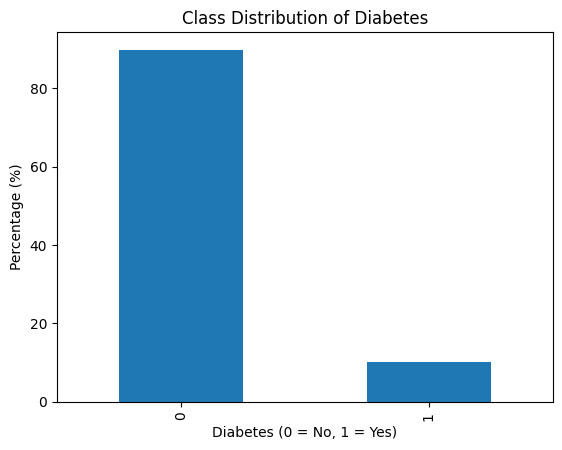

In [19]:
import matplotlib.pyplot as plt

# Compute percentage
diabetes_dist = df['diabetes'].value_counts(normalize=True) * 100

# Plot
plt.figure()
diabetes_dist.plot(kind='bar')

# Labels
plt.xlabel('Diabetes (0 = No, 1 = Yes)')
plt.ylabel('Percentage (%)')
plt.title('Class Distribution of Diabetes')

plt.show()

Data is highly imbalanced

Violin Plot

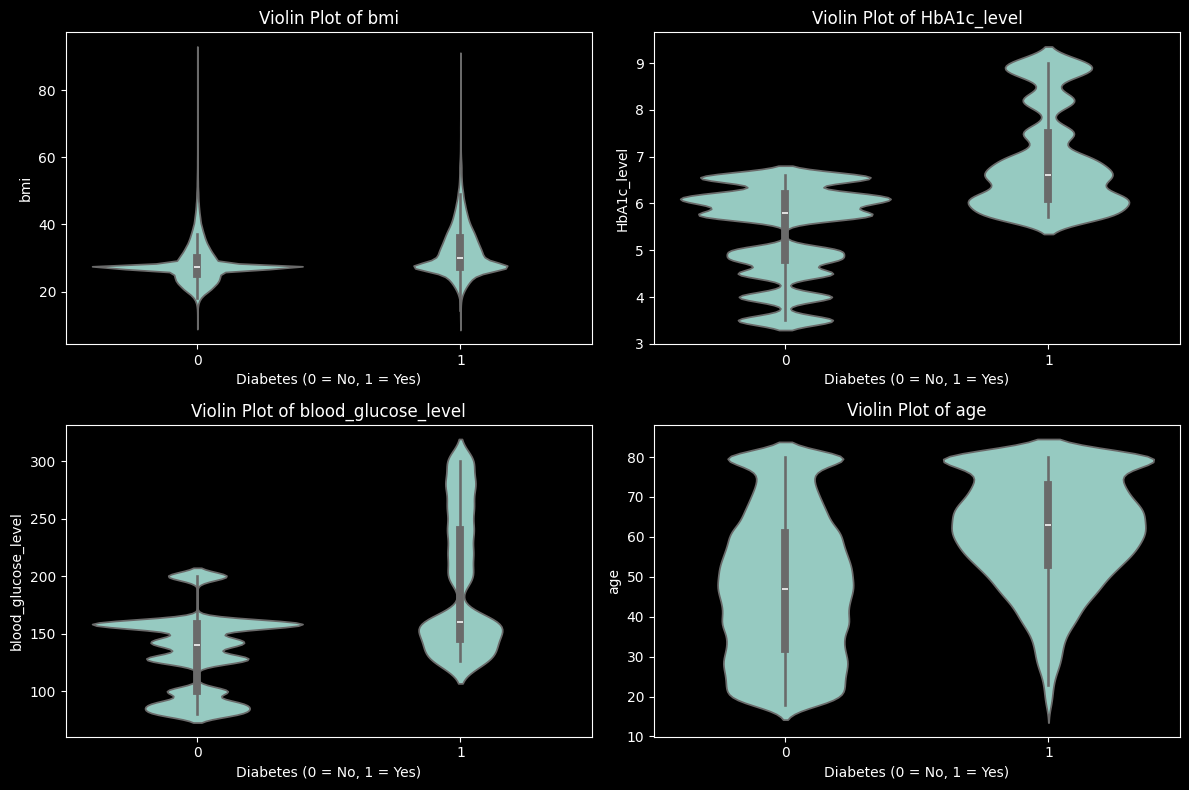

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dark theme (optional)
plt.style.use('dark_background')

# Your variables
cols = ['bmi', 'HbA1c_level', 'blood_glucose_level', 'age']

# Create grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# Plot violin plots
for i, col in enumerate(cols):
    sns.violinplot(data=df, x='diabetes', y=col, ax=axes[i])

    axes[i].set_title(f'Violin Plot of {col}')
    axes[i].set_xlabel('Diabetes (0 = No, 1 = Yes)')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

 Profile Plot of Numerical Variables by Diabetes Status

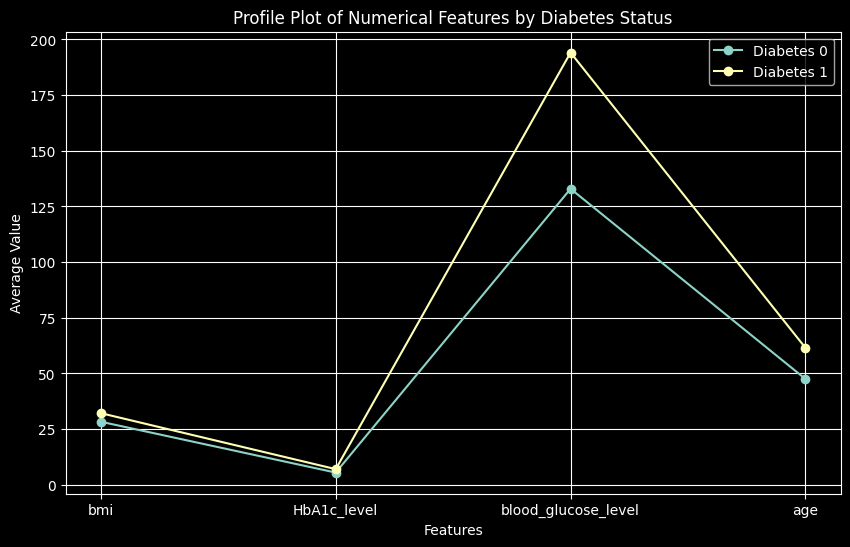

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Select your numerical features
cols = ['bmi', 'HbA1c_level', 'blood_glucose_level', 'age']

# Compute mean values grouped by diabetes
profile_data = df.groupby('diabetes')[cols].mean()

# Transpose for plotting (features on x-axis)
profile_data = profile_data.T

# Plot
plt.figure(figsize=(10, 6))

for i in profile_data.columns:
    plt.plot(profile_data.index, profile_data[i], marker='o', label=f'Diabetes {i}')

plt.xlabel('Features')
plt.ylabel('Average Value')
plt.title('Profile Plot of Numerical Features by Diabetes Status')
plt.legend()
plt.grid(True)

plt.show()

Distribution Plots

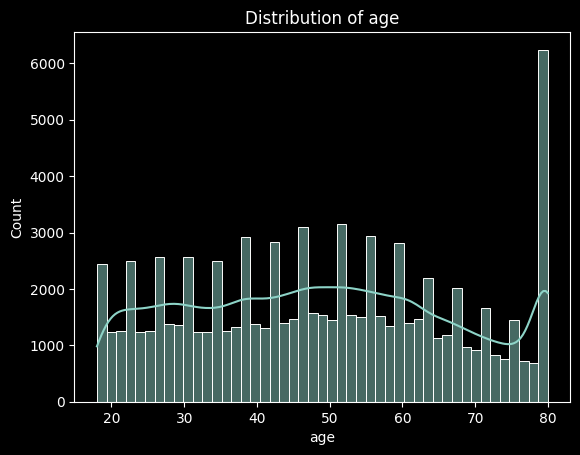

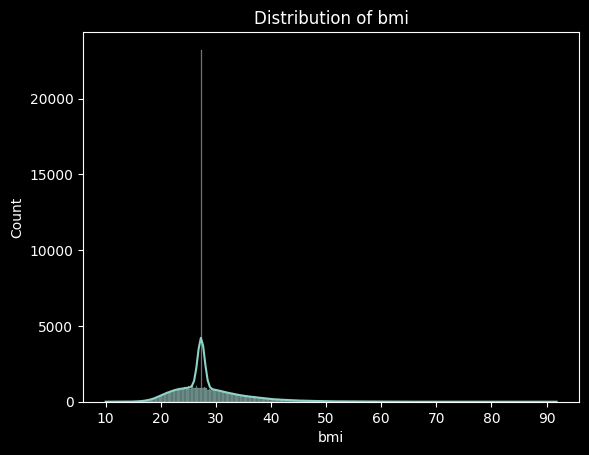

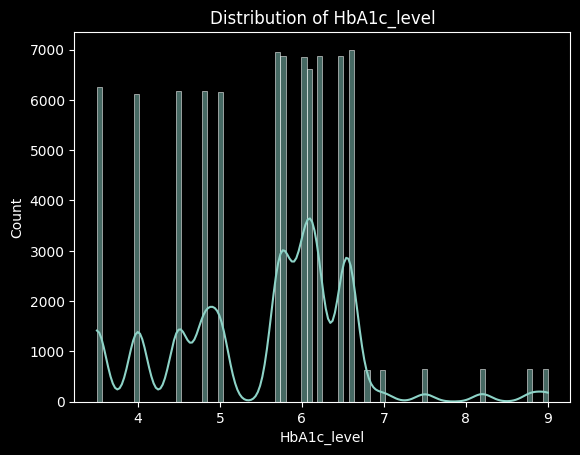

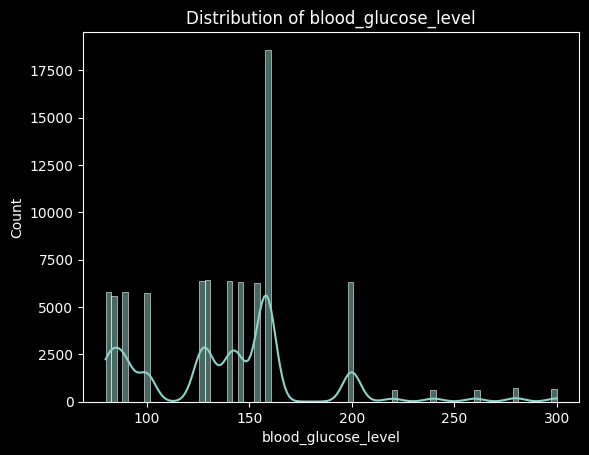

In [22]:

cols = ['age','bmi','HbA1c_level','blood_glucose_level']

for col in cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

Diabetes vs Features

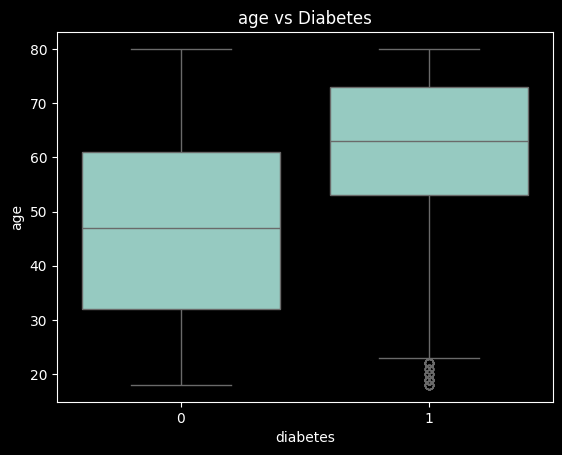

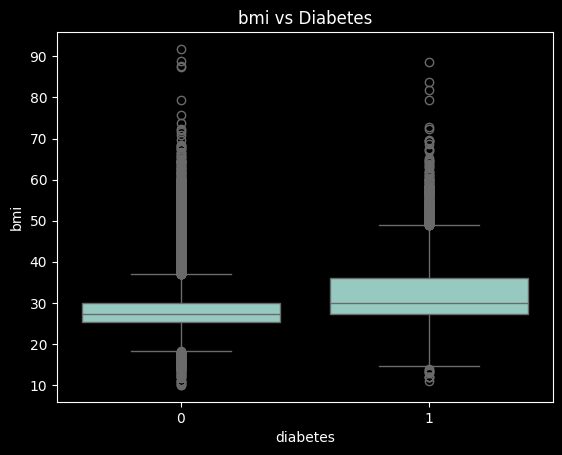

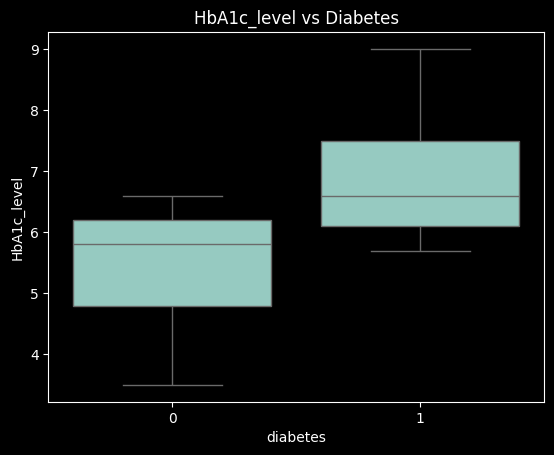

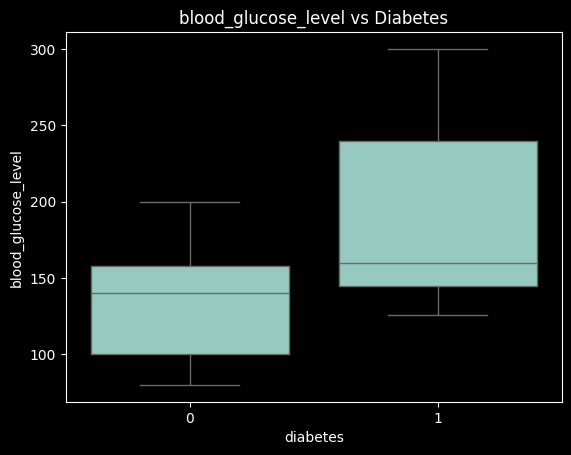

In [23]:
for col in cols:
    plt.figure()
    sns.boxplot(x='diabetes', y=col, data=df)
    plt.title(f"{col} vs Diabetes")
    plt.show()

Correlation Heatmap

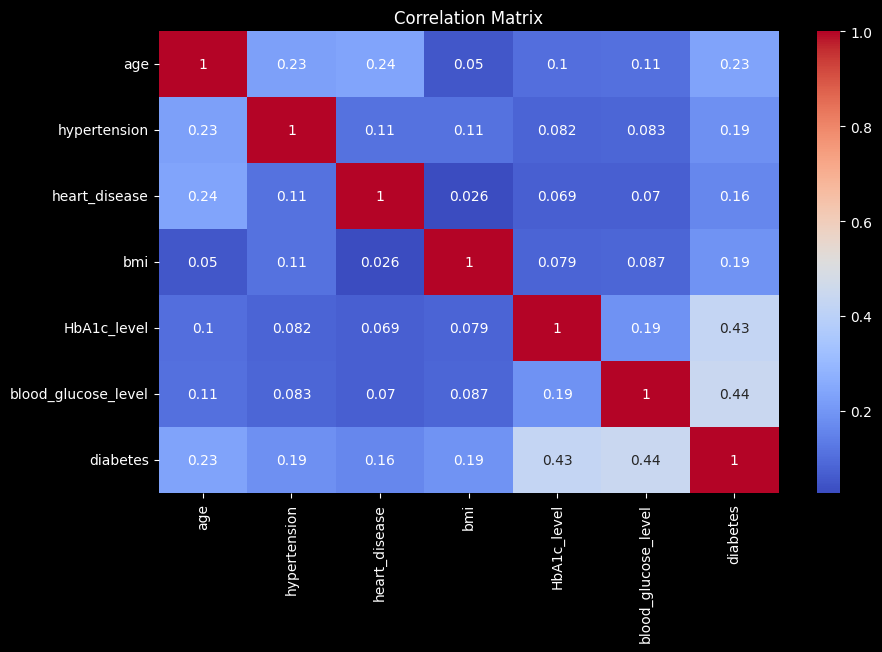

In [24]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Gender vs Diabetes

In [25]:
df.groupby(['gender','diabetes']).size().unstack()

diabetes,0,1
gender,,
Female,45683,4413
Male,28666,4005


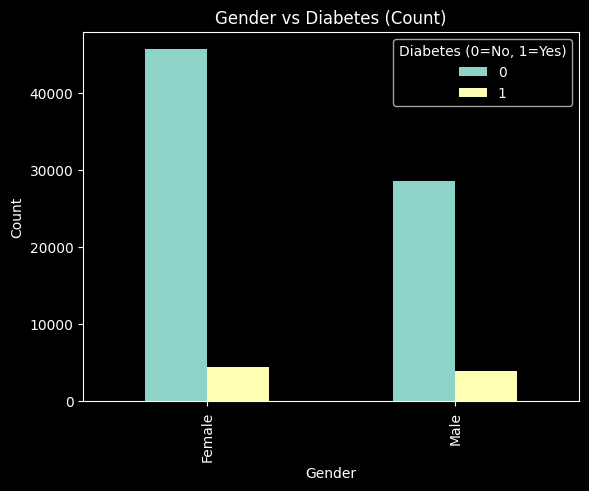

In [26]:
import matplotlib.pyplot as plt

# Create table
gender_diab = df.groupby(['gender', 'diabetes']).size().unstack().fillna(0)

# Plot
gender_diab.plot(kind='bar')

plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender vs Diabetes (Count)')
plt.legend(title='Diabetes (0=No, 1=Yes)')

plt.show()

In [27]:
df.groupby('gender')['diabetes'].mean()*100

,diabetes
gender,
Female,8.809087
Male,12.258578


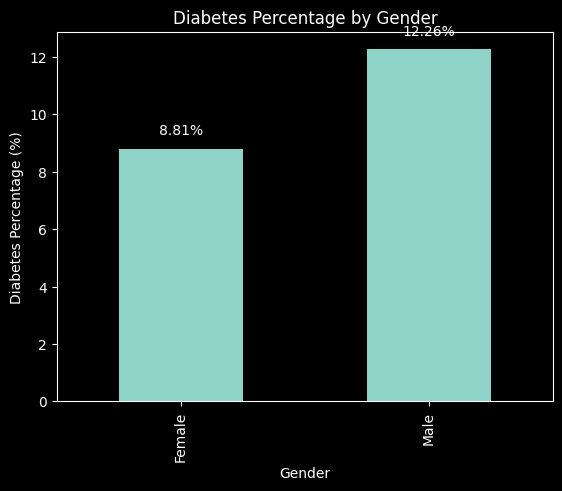

In [28]:
import matplotlib.pyplot as plt

# Your computed data
gender_pct = df.groupby('gender')['diabetes'].mean() * 100

# Plot
plt.figure()
gender_pct.plot(kind='bar')

# Labels
plt.xlabel('Gender')
plt.ylabel('Diabetes Percentage (%)')
plt.title('Diabetes Percentage by Gender')

# Add value labels
for i, v in enumerate(gender_pct):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.show()

Males show a noticeably higher prevalence of diabetes compared to females in the dataset.

In [29]:
df.groupby('diabetes').mean(numeric_only=True)

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level
diabetes,,,,,,
0,47.436253,0.072496,0.035925,28.232409,5.393962,132.868297
1,61.424566,0.248040,0.150392,32.081270,6.934842,194.044072


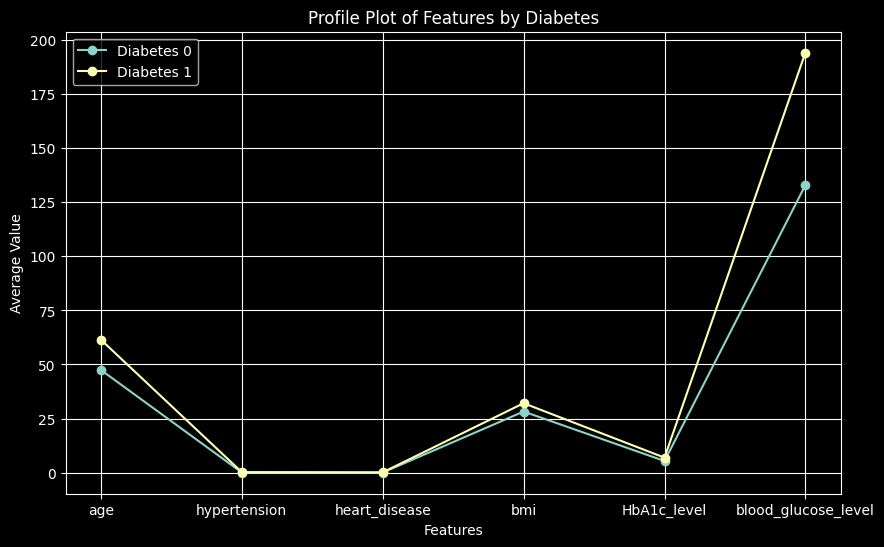

In [30]:
import matplotlib.pyplot as plt

# Compute means
mean_data = df.groupby('diabetes').mean(numeric_only=True)

# Transpose (features on x-axis)
mean_data = mean_data.T

# Plot
plt.figure(figsize=(10, 6))

for col in mean_data.columns:
    plt.plot(mean_data.index, mean_data[col], marker='o', label=f'Diabetes {col}')

plt.xlabel('Features')
plt.ylabel('Average Value')
plt.title('Profile Plot of Features by Diabetes')
plt.legend()
plt.grid(True)

plt.show()

People with diabetes:

Are older

Have higher BMI (obesity)

Have higher blood glucose levels

Have higher HbA1c levels

Are more likely to have:

Hypertension

Heart disease

In [31]:
df['gender'].value_counts()

,count
gender,
Female,50096
Male,32671


Age Groups Analysis

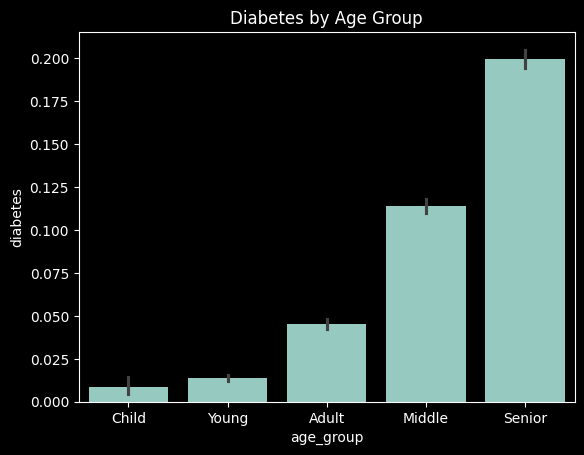

In [32]:
df['age_group'] = pd.cut(df['age'],
                        bins=[0,18,30,45,60,80],
                        labels=['Child','Young','Adult','Middle','Senior'])

sns.barplot(x='age_group', y='diabetes', data=df)
plt.title("Diabetes by Age Group")
plt.show()

Clustering

Churn Off

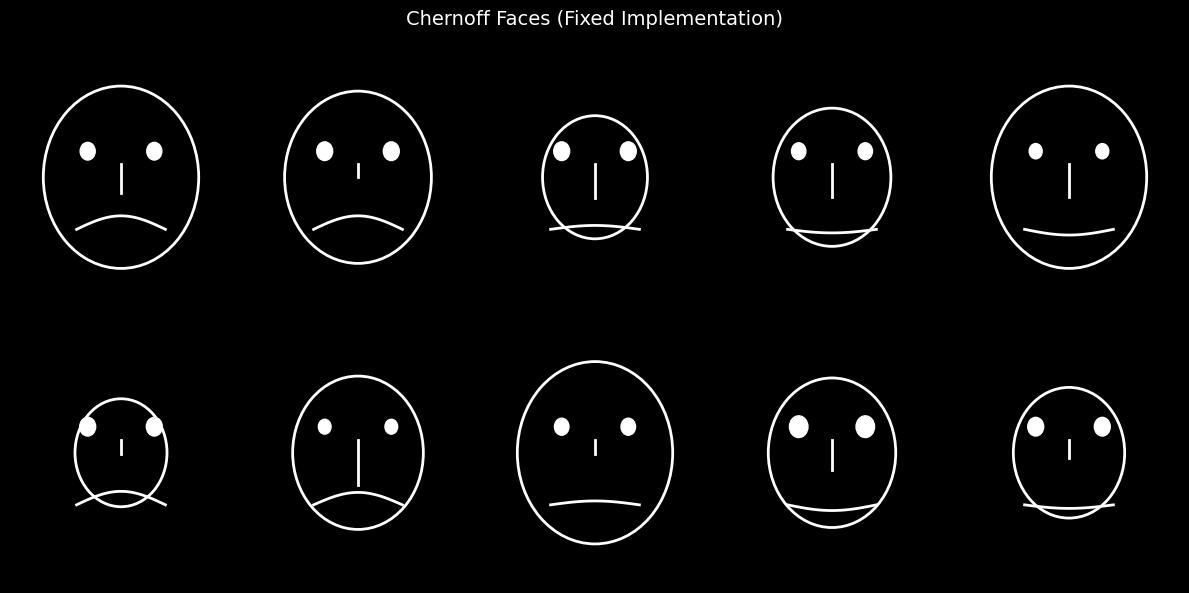

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# STEP 1: Select & Normalize Features
# -----------------------------
features = df[['age','bmi','HbA1c_level','blood_glucose_level']].copy()

# Min-Max Scaling (0 to 1)
features = (features - features.min()) / (features.max() - features.min())

# Slight boost for variation (important)
features = features * 1.5
features = features.clip(0, 1)

# -----------------------------
# STEP 2: Draw Face Function
# -----------------------------
def draw_face(ax, row):

    # Map features properly
    face_width = 0.4 + row['age'] * 0.3
    eye_size = 0.02 + row['bmi'] * 0.05
    mouth_curve = row['HbA1c_level']
    nose_length = 0.05 + row['blood_glucose_level'] * 0.15

    # Face (circle)
    face = plt.Circle((0.5, 0.5), face_width/2,
                      fill=False, color='white', linewidth=2)
    ax.add_patch(face)

    # Eyes
    ax.add_patch(plt.Circle((0.35, 0.6), eye_size, color='white'))
    ax.add_patch(plt.Circle((0.65, 0.6), eye_size, color='white'))

    # Nose (line)
    ax.plot([0.5, 0.5],
            [0.55, 0.55 - nose_length],
            color='white', linewidth=2)

    # Mouth (curve)
    x = np.linspace(0.3, 0.7, 100)
    y = 0.3 + 0.15 * (mouth_curve - 0.5) * np.sin((x-0.3)*np.pi/(0.4))
    ax.plot(x, y, color='white', linewidth=2)

    # Clean axes
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

# -----------------------------
# STEP 3: Plot Faces
# -----------------------------
plt.style.use('dark_background')

# Select only first 10 samples (important)
sample_data = features.iloc[:10]

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.flatten()):
    if i < len(sample_data):
        draw_face(ax, sample_data.iloc[i])

plt.suptitle("Chernoff Faces (Fixed Implementation)", fontsize=14)
plt.tight_layout()
plt.show()

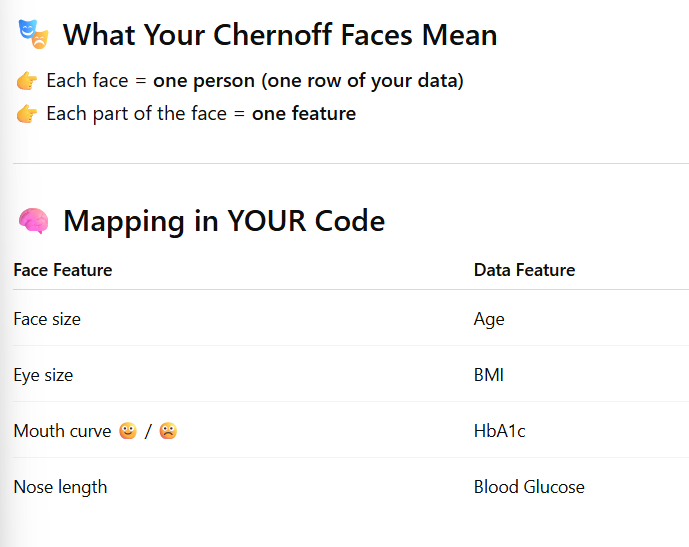

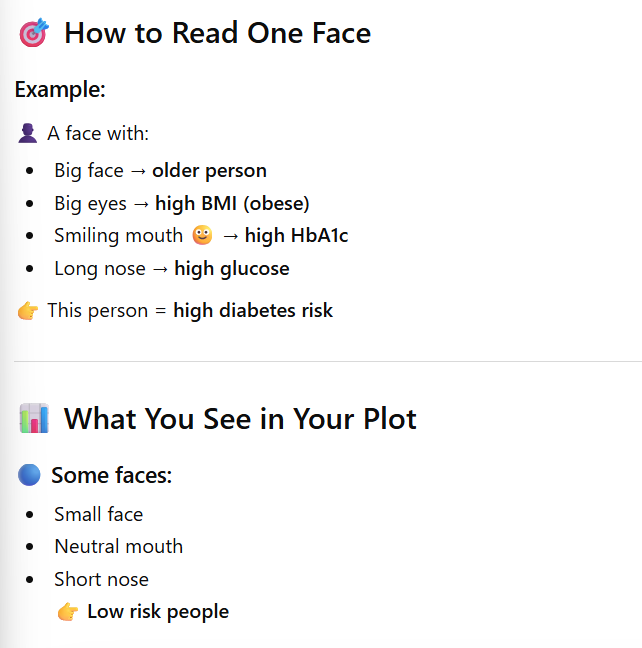

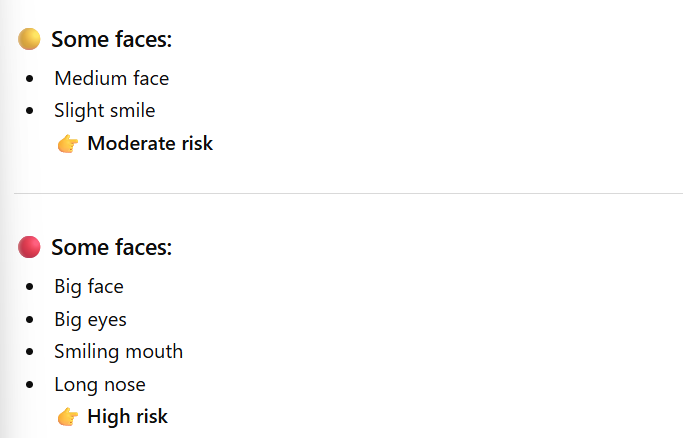

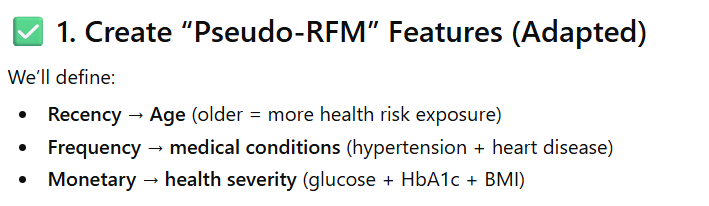

In [34]:
# Create RFM-like features
df_rfm = df.copy()

df_rfm['Recency'] = df_rfm['age']

df_rfm['Frequency'] = df_rfm['hypertension'] + df_rfm['heart_disease']

df_rfm['Monetary'] = (
    df_rfm['blood_glucose_level'] +
    df_rfm['HbA1c_level'] +
    df_rfm['bmi']
)

df_rfm = df_rfm[['Recency','Frequency','Monetary']]
df_rfm.head()

,Recency,Frequency,Monetary
0,80.0,1,171.79
1,54.0,0,113.92
2,28.0,0,191.02
3,36.0,0,183.45
4,76.0,2,179.94


2. Feature Scaling

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(df_rfm)

3. Determine Optimal Clusters

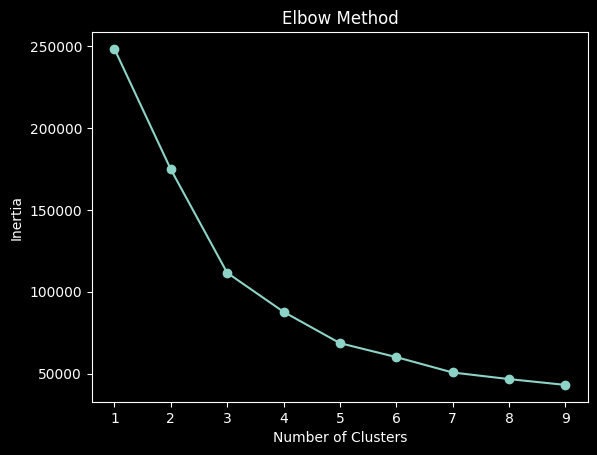

In [36]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Silhouette Analysis

from sklearn.metrics import silhouette_score

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"k={k}, Silhouette Score={score}")

The Elbow Method suggests an optimal number of clusters around 3–4, where inertia reduction slows significantly.
Although the Silhouette Score is highest at k = 7, using a larger number of clusters reduces interpretability.
Therefore, k = 3 was selected as the optimal number of clusters to balance model performance and interpretability.

Apply K-Means Clustering

In [37]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(rfm_scaled)

Analyze Clusters

In [38]:
df.groupby('Cluster').mean(numeric_only=True)

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
Cluster,,,,,,,
0,33.578509,0.000000,0.000000,27.907776,5.414411,128.441564,0.017821
1,62.607728,0.000000,0.000000,28.949567,5.623731,148.274883,0.144004
2,63.451186,0.712258,0.374988,30.301942,5.835470,150.497571,0.285361


Visualize Clusters

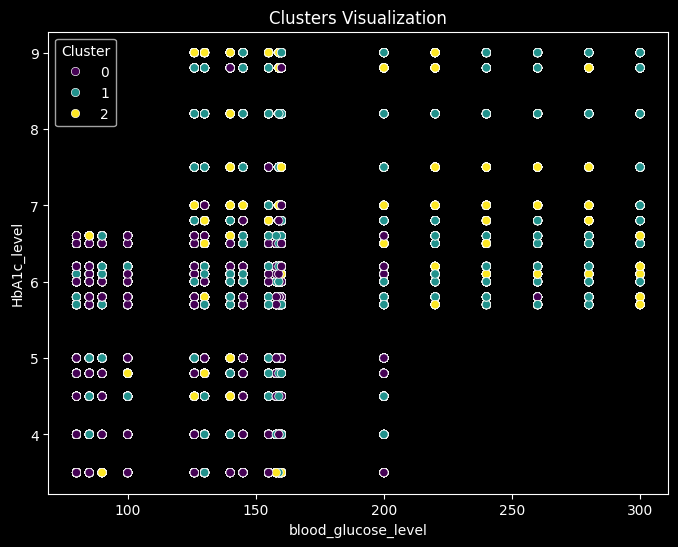

In [39]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['blood_glucose_level'],
    y=df['HbA1c_level'],
    hue=df['Cluster'],
    palette='viridis'
)
plt.title("Clusters Visualization")
plt.show()

3. Final Cluster Meaning (WRITE THIS IN REPORT)

🔵 Cluster 0 → Low Risk Group
Low blood glucose
Low HbA1c
Likely non-diabetic individuals

🟢 Cluster 1 → Medium Risk Group
Moderate glucose levels
Slightly elevated HbA1c
Pre-diabetic / at risk

🟡 Cluster 2 → High Risk Group
Very high glucose levels
High HbA1c
Strong likelihood of diabetes

3D Plot

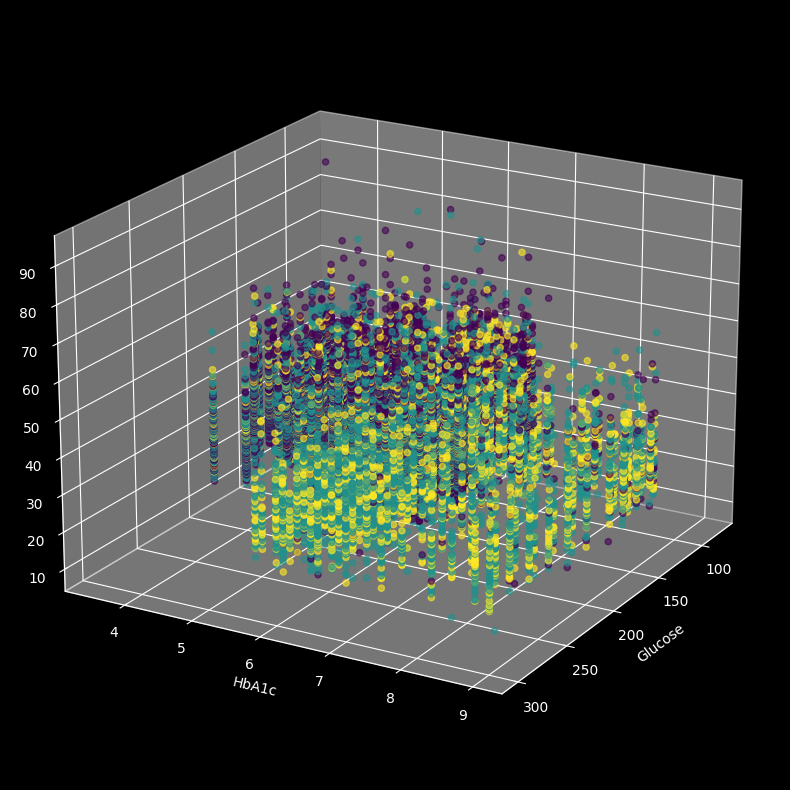

In [40]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['blood_glucose_level'],
    df['HbA1c_level'],
    df['bmi'],
    c=df['Cluster'],
    cmap='viridis',
    alpha=0.6
)

ax.set_xlabel('Glucose')
ax.set_ylabel('HbA1c')
ax.set_zlabel('BMI', labelpad=15)

ax.view_init(elev=20, azim=30)

plt.tight_layout()
plt.show()

The 3D visualization shows that clustering is primarily influenced by blood glucose and HbA1c levels, while BMI contributes less to cluster separation. Despite some overlap, distinct groups representing different risk levels are observable.

In [41]:
df.groupby('Cluster')['diabetes'].mean()*100

,diabetes
Cluster,
0,1.782053
1,14.400391
2,28.536051


The clustering results clearly separate individuals based on diabetes risk. Cluster 0 represents a low-risk group with minimal diabetes prevalence, Cluster 1 represents a moderate-risk group, and Cluster 2 represents a high-risk group with significantly higher diabetes prevalence.The clustering results clearly separate individuals based on diabetes risk. Cluster 0 represents a low-risk group with minimal diabetes prevalence, Cluster 1 represents a moderate-risk group, and Cluster 2 represents a high-risk group with significantly higher diabetes prevalence.

PCA

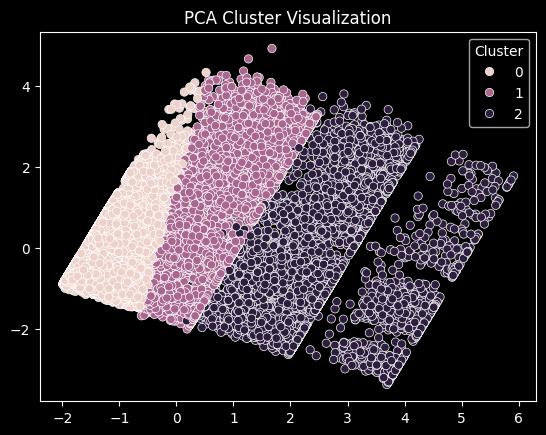

In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(rfm_scaled)

sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    hue=df['Cluster']
)
plt.title("PCA Cluster Visualization")
plt.show()

PCA-based visualization shows clear separation between clusters, indicating that the clustering algorithm successfully captured the underlying structure of the data. The clusters form distinct groups with minimal overlap, validating the effectiveness of the segmentation.

apply heirarchical clustering

3,000 patients

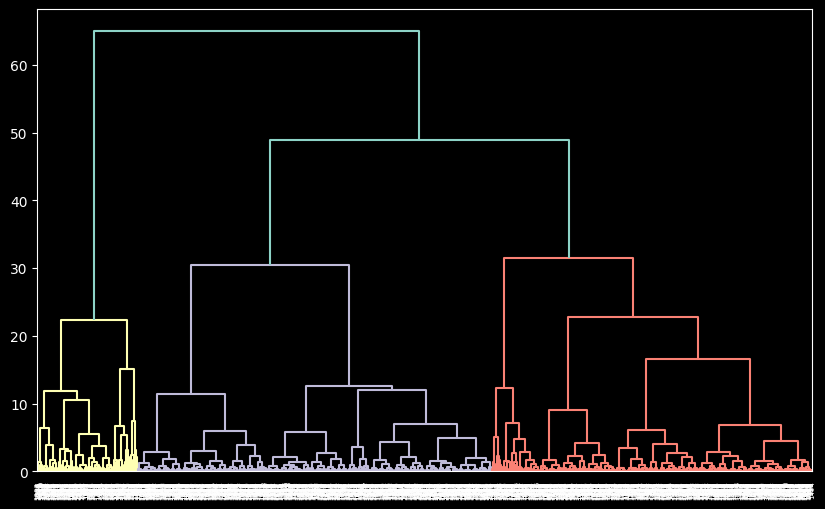

In [43]:
# Take small sample
df_sample = df_rfm.sample(n=2000, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_sample_scaled = scaler.fit_transform(df_sample)

from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(rfm_sample_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.show()

Diesease Basket Analysis

Step 1: Create Transaction Data

In [44]:
df_mba = df.copy()

# Create categorical items
df_mba['High_Glucose'] = df['blood_glucose_level'] > 180
df_mba['High_HbA1c'] = df['HbA1c_level'] > 6.5
df_mba['Obese'] = df['bmi'] > 30
df_mba['Old_Age'] = df['age'] > 50
df_mba['Hypertension'] = df['hypertension'] == 1
df_mba['Heart_Disease'] = df['heart_disease'] == 1

df_mba = df_mba[['High_Glucose','High_HbA1c','Obese','Old_Age','Hypertension','Heart_Disease']]

Step 2: Convert to Transaction Format

In [45]:
df_mba = df_mba.astype(int)
df_mba.head()

,High_Glucose,High_HbA1c,Obese,Old_Age,Hypertension,Heart_Disease
0,0,1,0,1,0,1
1,0,1,0,1,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,1,1,1


Step 3: Apply Apriori Algorithm

In [46]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_items = apriori(df_mba, min_support=0.05, use_colnames=True)

rules = association_rules(frequent_items, metric="confidence", min_threshold=0.5)

rules.head()

/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(High_Glucose),(Old_Age),0.115312,0.464678,0.066838,0.579631,1.247383,1.0,0.013255,1.273458,0.224171,0.130251,0.214737,0.361734
1,(High_HbA1c),(Old_Age),0.131163,0.464678,0.075924,0.578850,1.245702,1.0,0.014975,1.271097,0.227016,0.146031,0.213278,0.371120
2,(Hypertension),(Old_Age),0.090350,0.464678,0.071103,0.786975,1.693593,1.0,0.029120,2.512956,0.450216,0.146930,0.602062,0.469996


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


The association rule mining reveals strong relationships between health conditions. High glucose and HbA1c levels are moderately associated with older age, while hypertension shows a strong association with older individuals (confidence ~79%, lift ~1.69). These findings align with real-world medical knowledge.

Filter Strong Rules

In [47]:
rules = rules.sort_values(by='confidence', ascending=False)

rules[['antecedents','consequents','support','confidence','lift']].head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
2,(Hypertension),(Old_Age),0.071103,0.786975,1.693593
0,(High_Glucose),(Old_Age),0.066838,0.579631,1.247383
1,(High_HbA1c),(Old_Age),0.075924,0.578850,1.245702


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Top Rules by Confidence

In [48]:
rules.sort_values(by='confidence', ascending=False).head(5)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2,(Hypertension),(Old_Age),0.090350,0.464678,0.071103,0.786975,1.693593,1.0,0.029120,2.512956,0.450216,0.146930,0.602062,0.469996
0,(High_Glucose),(Old_Age),0.115312,0.464678,0.066838,0.579631,1.247383,1.0,0.013255,1.273458,0.224171,0.130251,0.214737,0.361734
1,(High_HbA1c),(Old_Age),0.131163,0.464678,0.075924,0.578850,1.245702,1.0,0.014975,1.271097,0.227016,0.146031,0.213278,0.371120


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Top Rules by Support

In [49]:
rules.sort_values(by='support', ascending=False).head(5)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1,(High_HbA1c),(Old_Age),0.131163,0.464678,0.075924,0.578850,1.245702,1.0,0.014975,1.271097,0.227016,0.146031,0.213278,0.371120
2,(Hypertension),(Old_Age),0.090350,0.464678,0.071103,0.786975,1.693593,1.0,0.029120,2.512956,0.450216,0.146930,0.602062,0.469996
0,(High_Glucose),(Old_Age),0.115312,0.464678,0.066838,0.579631,1.247383,1.0,0.013255,1.273458,0.224171,0.130251,0.214737,0.361734


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Top Rules by Lift

In [50]:
rules.sort_values(by='lift', ascending=False).head(5)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2,(Hypertension),(Old_Age),0.090350,0.464678,0.071103,0.786975,1.693593,1.0,0.029120,2.512956,0.450216,0.146930,0.602062,0.469996
0,(High_Glucose),(Old_Age),0.115312,0.464678,0.066838,0.579631,1.247383,1.0,0.013255,1.273458,0.224171,0.130251,0.214737,0.361734
1,(High_HbA1c),(Old_Age),0.131163,0.464678,0.075924,0.578850,1.245702,1.0,0.014975,1.271097,0.227016,0.146031,0.213278,0.371120


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Classsification

In [51]:
df.head(5)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,age_group,Cluster
0,Female,80.0,0,1,25.19,6.6,140,0,Senior,2
1,Female,54.0,0,0,27.32,6.6,80,0,Middle,0
2,Male,28.0,0,0,27.32,5.7,158,0,Young,0
3,Female,36.0,0,0,23.45,5.0,155,0,Adult,0
4,Male,76.0,1,1,20.14,4.8,155,0,Senior,2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [52]:
df.drop(columns=['Cluster'],inplace=True)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [53]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [54]:
df.head(5)

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,age_group
0,Female,80.0,0,1,25.19,6.6,140,0,Senior
1,Female,54.0,0,0,27.32,6.6,80,0,Middle
2,Male,28.0,0,0,27.32,5.7,158,0,Young
3,Female,36.0,0,0,23.45,5.0,155,0,Adult
4,Male,76.0,1,1,20.14,4.8,155,0,Senior


In [55]:
df.age_group.value_counts()

,count
age_group,
Senior,23632
Middle,22486
Adult,20142
Young,15327
Child,1180


In [56]:
age_order = {
    'Child': 0,
    'Young': 1,
    'Adult': 2,
    'Middle': 3,
    'Senior': 4
}

df['age_group_encoded'] = df['age_group'].map(age_order)

In [57]:
df[['age_group', 'age_group_encoded']].head()

,age_group,age_group_encoded
0,Senior,4
1,Middle,3
2,Young,1
3,Adult,2
4,Senior,4


In [58]:
df.drop(columns=['age_group'],inplace=True)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82767 entries, 0 to 99981
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   gender               82767 non-null  object  
 1   age                  82767 non-null  float64 
 2   hypertension         82767 non-null  int64   
 3   heart_disease        82767 non-null  int64   
 4   bmi                  82767 non-null  float64 
 5   HbA1c_level          82767 non-null  float64 
 6   blood_glucose_level  82767 non-null  int64   
 7   diabetes             82767 non-null  int64   
 8   age_group_encoded    82767 non-null  category
dtypes: category(1), float64(3), int64(4), object(1)
memory usage: 5.8+ MB


In [60]:
df['gender_encoded'] = df['gender'].map({
    'Male': 0,
    'Female': 1
})

In [61]:
df[['gender', 'gender_encoded']].head()

,gender,gender_encoded
0,Female,1
1,Female,1
2,Male,0
3,Female,1
4,Male,0


In [62]:
df.drop(columns=['gender'],inplace=True)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82767 entries, 0 to 99981
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   age                  82767 non-null  float64 
 1   hypertension         82767 non-null  int64   
 2   heart_disease        82767 non-null  int64   
 3   bmi                  82767 non-null  float64 
 4   HbA1c_level          82767 non-null  float64 
 5   blood_glucose_level  82767 non-null  int64   
 6   diabetes             82767 non-null  int64   
 7   age_group_encoded    82767 non-null  category
 8   gender_encoded       82767 non-null  int64   
dtypes: category(1), float64(3), int64(5)
memory usage: 5.8 MB


In [64]:
df["age_group_encoded"] = df["age_group_encoded"].astype("int64")

In [65]:
df = df.dropna()

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82767 entries, 0 to 99981
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  82767 non-null  float64
 1   hypertension         82767 non-null  int64  
 2   heart_disease        82767 non-null  int64  
 3   bmi                  82767 non-null  float64
 4   HbA1c_level          82767 non-null  float64
 5   blood_glucose_level  82767 non-null  int64  
 6   diabetes             82767 non-null  int64  
 7   age_group_encoded    82767 non-null  int64  
 8   gender_encoded       82767 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 6.3 MB


In [67]:
df.diabetes.value_counts()


,count
diabetes,
0,74349
1,8418


Preparing the data for model training

In [68]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [70]:
print(X_train.isna().sum())
print(X_test.isna().sum())

age                    0
hypertension           0
heart_disease          0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
age_group_encoded      0
gender_encoded         0
dtype: int64
age                    0
hypertension           0
heart_disease          0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
age_group_encoded      0
gender_encoded         0
dtype: int64


applying Smote

In [74]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

Scaling the date

In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sm = scaler.fit_transform(X_train_sm)
X_test = scaler.transform(X_test)

FINAL MODEL COMPARISON CODE

In [82]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE

Scaling

In [83]:
scaler = StandardScaler()
X_train_sm_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

In [84]:
models = {
    "LDA": LinearDiscriminantAnalysis(),
    "Logistic": LogisticRegression(max_iter=500),
    "SVM": SVC(kernel='rbf', probability=True),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "CART": DecisionTreeClassifier(
        criterion="gini",
        max_depth=5,
        min_samples_split=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42
    ),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(64,32),
        max_iter=300,
        random_state=42
    )
}

Train & Evaluate All Models

In [85]:

from sklearn.metrics import precision_score
results = []

for name, model in models.items():

    # use scaled data for SVM & MLP
    if name in ["SVM", "MLP", "Logistic"]:
        X_tr, X_te = X_train_sm_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train_sm, X_test

    model.fit(X_tr, y_train_sm)

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Diabetes)": precision_score(y_test, y_pred),
        "Recall (Diabetes)": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

Show Comparison Table

In [86]:
results_df = pd.DataFrame(results).sort_values(by="AUC", ascending=False)
print(results_df)

           Model  Accuracy  Precision (Diabetes)  Recall (Diabetes)  F1 Score  \
6            MLP  0.911925              0.540348           0.821901  0.652029   
5  Random Forest  0.911864              0.539265           0.838748  0.656463   
4           CART  0.871330              0.430024           0.865223  0.574511   
2            SVM  0.883533              0.457858           0.869434  0.599834   
1       Logistic  0.883714              0.456758           0.835740  0.590687   
0            LDA  0.887278              0.465587           0.830325  0.596628   
3  Decision Tree  0.939592              0.690668           0.721420  0.705709   

        AUC  
6  0.964605  
5  0.961254  
4  0.953112  
2  0.951907  
1  0.948259  
0  0.945704  
3  0.844836  


Plot Comparison

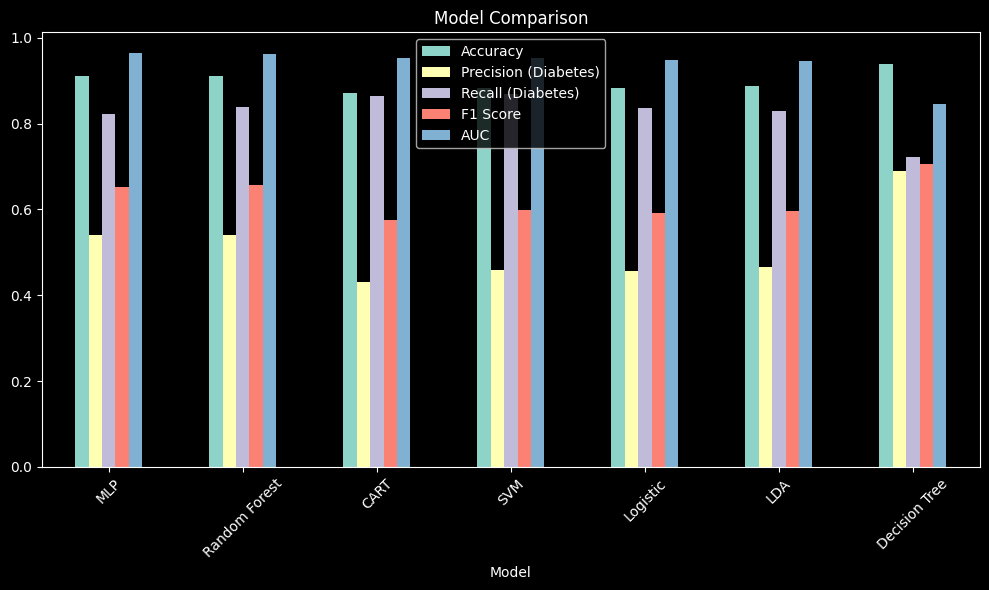

In [90]:
import matplotlib.pyplot as plt

results_df.set_index("Model")[[
    "Accuracy",
    "Precision (Diabetes)",
    "Recall (Diabetes)",
    "F1 Score",
    "AUC"
]].plot(kind="bar", figsize=(10,6))

plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ROC Curve for All Models

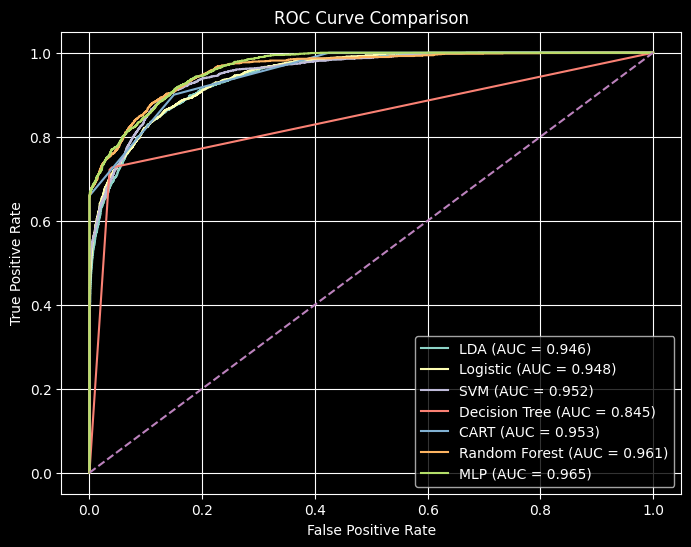

In [88]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

roc_data = {}

for name, model in models.items():

    # use same scaling logic as before
    if name in ["SVM", "MLP", "Logistic"]:
        X_te = X_test_scaled
    else:
        X_te = X_test

    # predictions
    y_prob = model.predict_proba(X_te)[:, 1]

    # ROC values
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    roc_data[name] = (fpr, tpr, auc)

# -------- Plot --------
plt.figure(figsize=(8,6))

for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')  # random model line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()

plt.show()